Data generated by Todd is missing alpha's and delta's for intermediate potentials - probably to keep data clean and accurate and not get bogged down by experimental error <br>
I am going to calculate my own kinetic parameters and cross verify with Todd's data by plotting <br>
Experimental parameters: <br>
KOH/HClO4 concs: 0.1, 0.25, 0.5, 1 (M) <br>
CO Pressure: 0.1, 1, 10, 100 <br>
16 different condiitons for each acidic/basic CO oxidation: 4 different setups <br>
Assume that pH reaction order data will be less accurate than CO reaction order or transfer coefficient data - different setups for different pHs <br>
Potential ranges: 0.5 - 1 (vs RHE) <br>
Catalysts: Pt100, Pt66Ru33, Pt50Ru50 <br>
<br>
Units: <br>
Potential: V vs RHE <br>
Current: mA/cm2 <br>
<br>
This time data has replicates (4 replicates for each condition) <br>
Data was interpolated (Pchipinterpolation) to put all data sets on the same grid. <br>
Savgol is currently not working. <br>
Calculate mean and SD for each data point (current first). <br> 
Calculate mean and SD for KOs. Calculate individual KOs first and then average. <br>
Save final data and import in different workspace. <br>

Data is now truncated to i_max in each case to remove current that is affected by oxidized surface (formation of extra oxidized species like O*). <br>

# Initialization

In [ ]:
# Block 1: All import statements (should reamin mostly unchanged) 
# Block 2: Define experimental conditions, constans and other control variables (buffer after minima, number of points the whole dataset is being condensed to) (should be mostly unchanged)
# Block 3: Load data for excel file (should be mostly unchanged) (Data is current density (mA/cm^2) vs E_RHE for different experimental conditions - with 4 replicates each) 
# Block 4: 
#   a. Map raw data onto SHE scale. Convert current density to rate. 
#   b. Smoothen data (SG - commented out for now - but it should work when uncommented)
#   c. Only select data for each experimental conditon which is common between all replicates (largest value of E_min and smallest value of E_max - so replicates are present for the entire range)  
#   d. Interpolate data to a coarser grid (number of points is defined in block 2). The end points will differ between experimental condtions (but the size of the grid will be the same - becuase the size of the range is more or less the same) 
#       Question: How do I make sure that the points that can be common between all the experimental conditions are common? For example, one experimental condition (and its replicates) might be between -0.1 and 0.4, while the other experimental condtion might be between 
#       -0.05 and 0.45. I want the points between -0.05 and 0.4 to be the same between both experimental condtions. This makes post-processing easier - makes it easy to calculate delta_CO and delta_OH which I have been ignoring right now. This might mess up the exact start
#       and end points, but that is no big deal. dE must be the same and constant for all data. 
#   e. Average the data to calculate mean and SD at each experimental condition (using the replicates). 
#   f. Calculate alpha for each experimental condtion and find the minima. 
#   g. Truncate the data for each experimental condition to the minima (+ include certain number of points after the minima - as defined by the buffer in block 2). Data after mimima is likely to be from oxidized surface and is accurate. 
#   h. Save the (truncated) potentials, rate mean and rate SD for each experimental condition. 
# Block 5: Calculate (mean and SD of) alphas using untruncated data and save them. This is for plotting reference. (Use coarse grid)
# Block 6: Calculate (mean and SD of) delta_CO using untruncated data and save them. Truncate data to common SHE grid (as is neccessary). This is for plotting reference. (Use coarse grid) 
# Block 7: Calculate (mean and SD of) delta_OH using untruncated data and save them. Truncate data to common SHE grid (as is neccessary). This is for plotting reference. (Use coarse grid)

# I already have plotting code; it should not change unless there are errors. Do not change variable names unless necessary - it might break post processing (indicate any changes in variable names). 
# Current code for calculating delta_CO and delta_OH is more broken than usual - it's old and hasn't been adapted for truncated data (or data with different start and end points).


In [1]:
import pandas as pd
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from scipy.signal import savgol_filter

import sys
import os 
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import _utils

In [ ]:
# Experimental conditions (Pt100 KOH) and constants

C_KOH_list = np.array([0.1, 0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
trials = [1, 2, 3, 4]
conditions = list(itertools.product(C_KOH_list, P_CO_list))
conditions_trials = list(itertools.product(C_KOH_list, P_CO_list, trials))

R, T, F = 8.3145, 298.15, 96485
n = 2 # number of electrons transferred in the reaction

number_of_points = 50

# Set to 0 to cut exactly at min alpha (current behavior)
# Set to an integer (e.g., 10) to include 10 points after the peak
# Set to None to include ALL data (no truncation)
buffer_after_min = None

In [3]:
# Load current density data + classification

excel_file = 'Summary_Pt_replicates.xlsx'
experiments = {}
for C_KOH in C_KOH_list: 
    for trial in trials: 
        sheet_name = f'{int(C_KOH*1000)} mM KOH - Trial {trial}'
        df = pd.read_excel(excel_file, sheet_name=sheet_name, header=None)
        for i, P_CO in enumerate(P_CO_list): 
            col_idx = i * 2
            subset = df.iloc[2:, col_idx : col_idx+2].copy()
            subset.columns = ['E', 'j']
            # Force numeric, coerce bad values/text to NaN, then drop
            subset['E'] = pd.to_numeric(subset['E'], errors='coerce')
            subset['j'] = pd.to_numeric(subset['j'], errors='coerce')
            subset = subset.dropna()
            experiments[(C_KOH, P_CO, trial)] = subset

# Smoothing and Interpolating

In [4]:
# 1. Select the common RHE range
global_min_E = max(df['E'].min() for df in experiments.values())
global_max_E = min(df['E'].max() for df in experiments.values())

experiments_interp = {}
experiments_mean = {}

for P_CO in P_CO_list:
    for C_KOH in C_KOH_list:
        # 2. Convert to SHE and setup the common interpolated grid
        E_ref = -0.0592 * (14 + np.log10(C_KOH))
        E_grid_SHE = np.linspace(global_min_E + E_ref, global_max_E + E_ref, number_of_points)
        
        buffer_pts = buffer_after_min if buffer_after_min is not None else 0
        
        trials_data = {}
        cutoffs = []
        for trial in trials:
            cond = (C_KOH, P_CO, trial)
            df = experiments[cond]
            df_trunc = df[(df['E'] >= global_min_E) & (df['E'] <= global_max_E)]
            
            # 3. Interpolate to coarser SHE grid
            rate_interp = PchipInterpolator(df_trunc['E'] + E_ref, df_trunc['j'] / (1000 * n * F))(E_grid_SHE)
            log_rate_interp = np.log(rate_interp)
            
            # 4. Calculate alpha and find truncation index
            alpha = (R * T / F) * np.gradient(log_rate_interp, E_grid_SHE)
            if buffer_after_min is not None:
                cutoffs.append(np.argmin(alpha[5:]) + 5 + buffer_pts)
            else:
                cutoffs.append(number_of_points)
                
            trials_data[trial] = {'rate': rate_interp, 'log_rate': log_rate_interp}
            
        # 5. Truncate uniformly to the max cutoff to ensure equal lengths
        final_cut = min(max(cutoffs), number_of_points)
        E_final = E_grid_SHE[:final_cut]
        
        rate_mat = []
        log_rate_mat = []
        
        # 6. Build final datasets and average
        for trial in trials:
            cond = (C_KOH, P_CO, trial)
            r_final = trials_data[trial]['rate'][:final_cut]
            lr_final = trials_data[trial]['log_rate'][:final_cut]
            
            experiments_interp[cond] = {
                'E': E_final,
                'rate': r_final,
                'log_rate': lr_final
            }
            rate_mat.append(r_final)
            log_rate_mat.append(lr_final)
            
        experiments_mean[(C_KOH, P_CO)] = {
            'E': E_final,
            'rate': np.mean(rate_mat, axis=0),
            'rate_SD': np.std(rate_mat, axis=0, ddof=1),
            'log_rate': np.mean(log_rate_mat, axis=0),
            'log_rate_SD': np.std(log_rate_mat, axis=0, ddof=1)
        }

# Currents

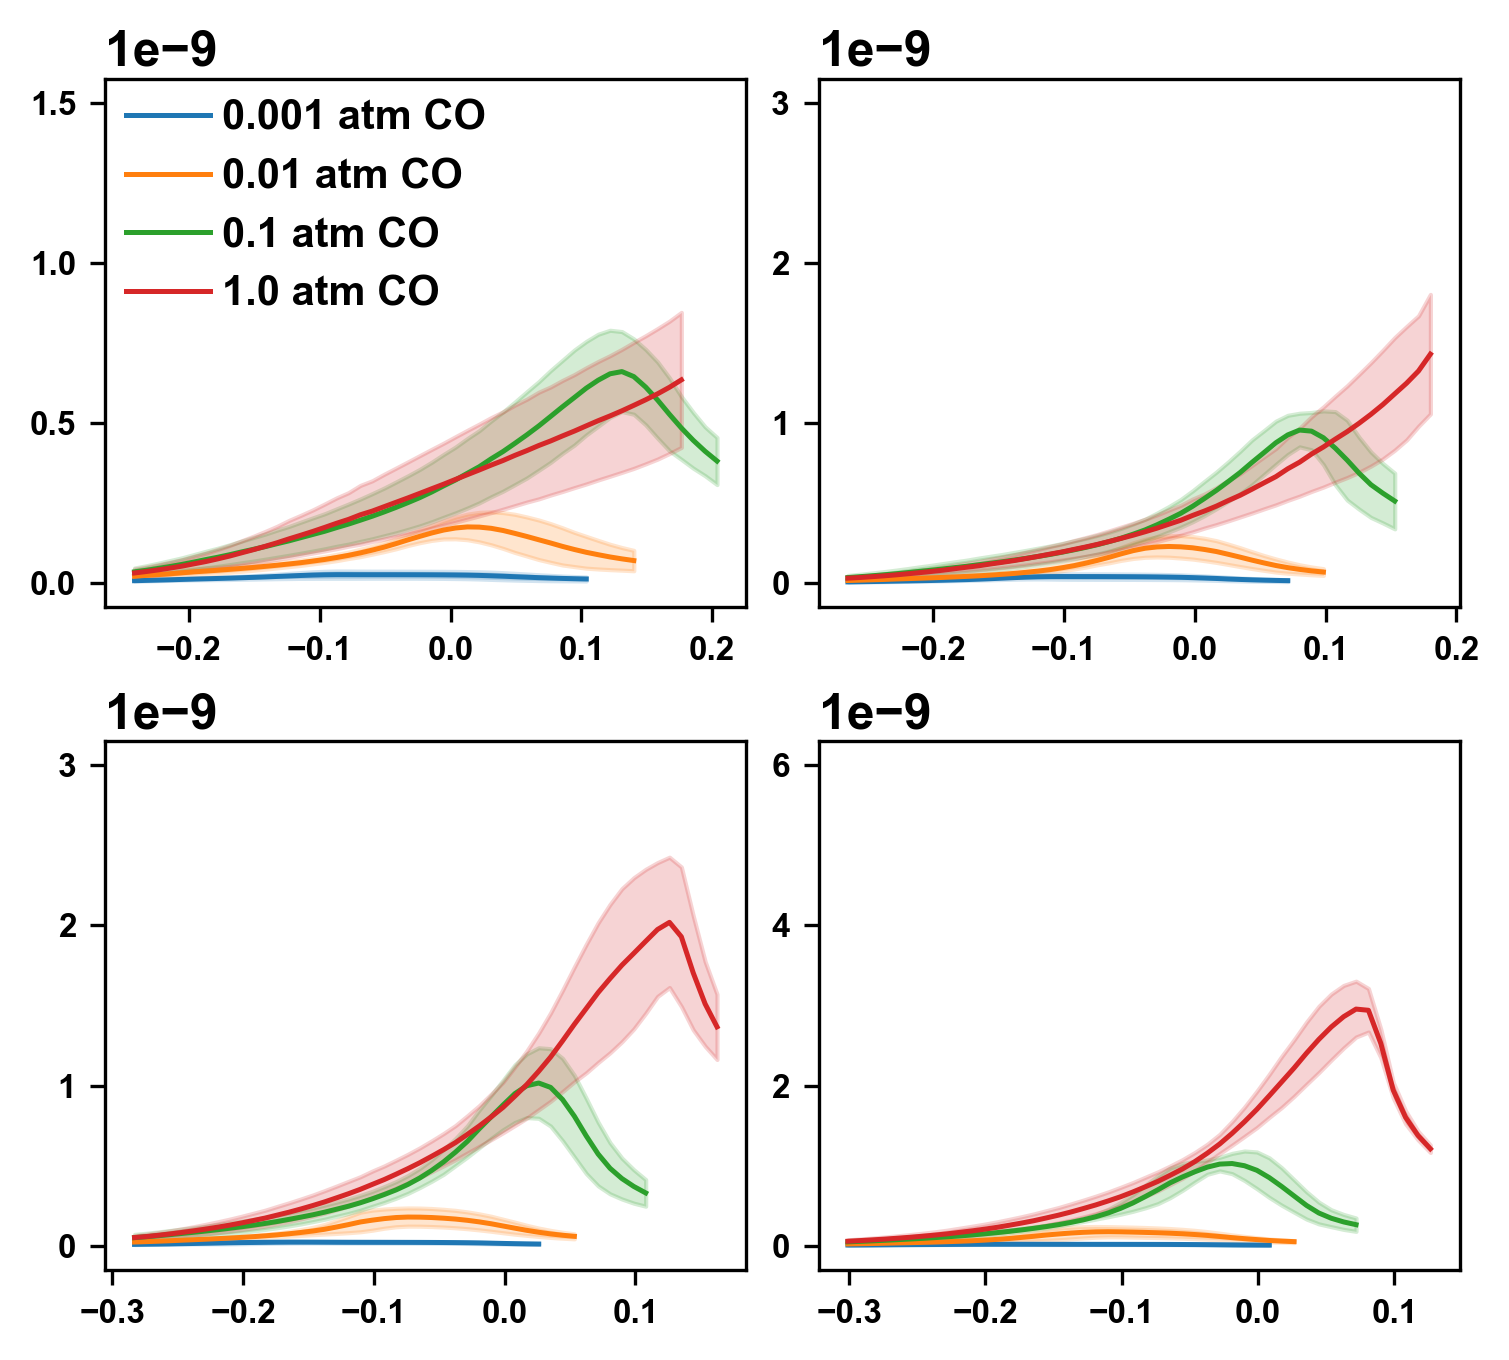

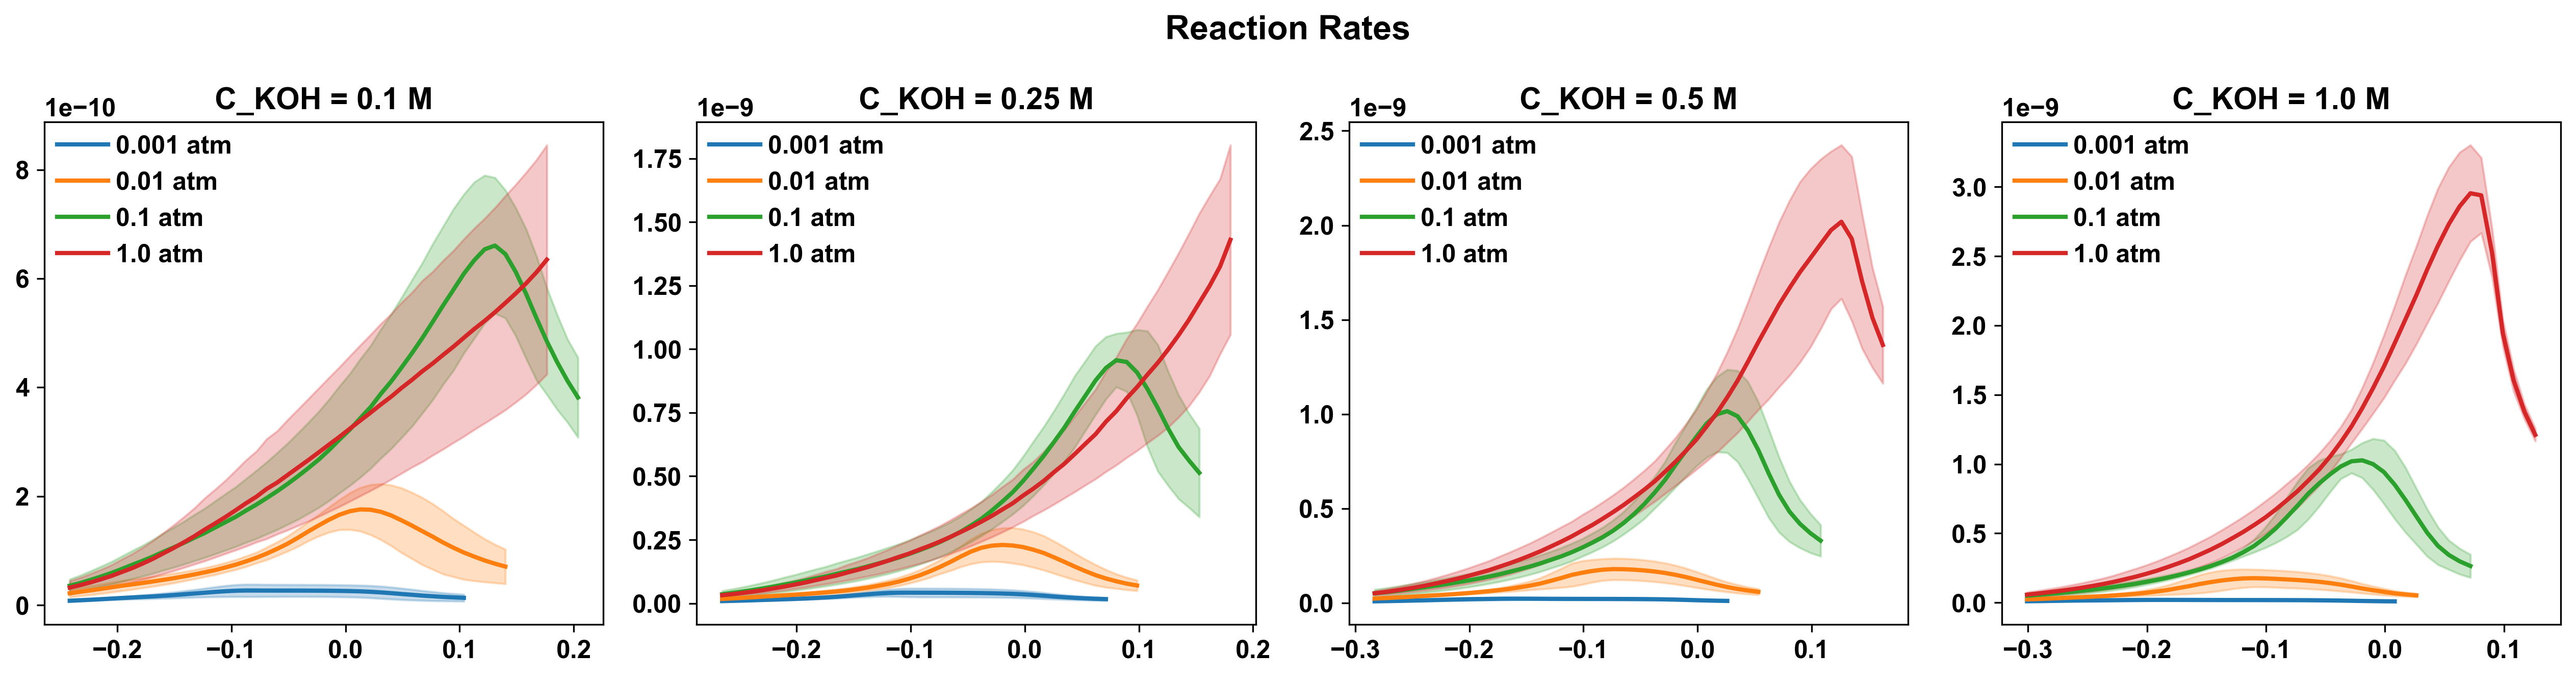

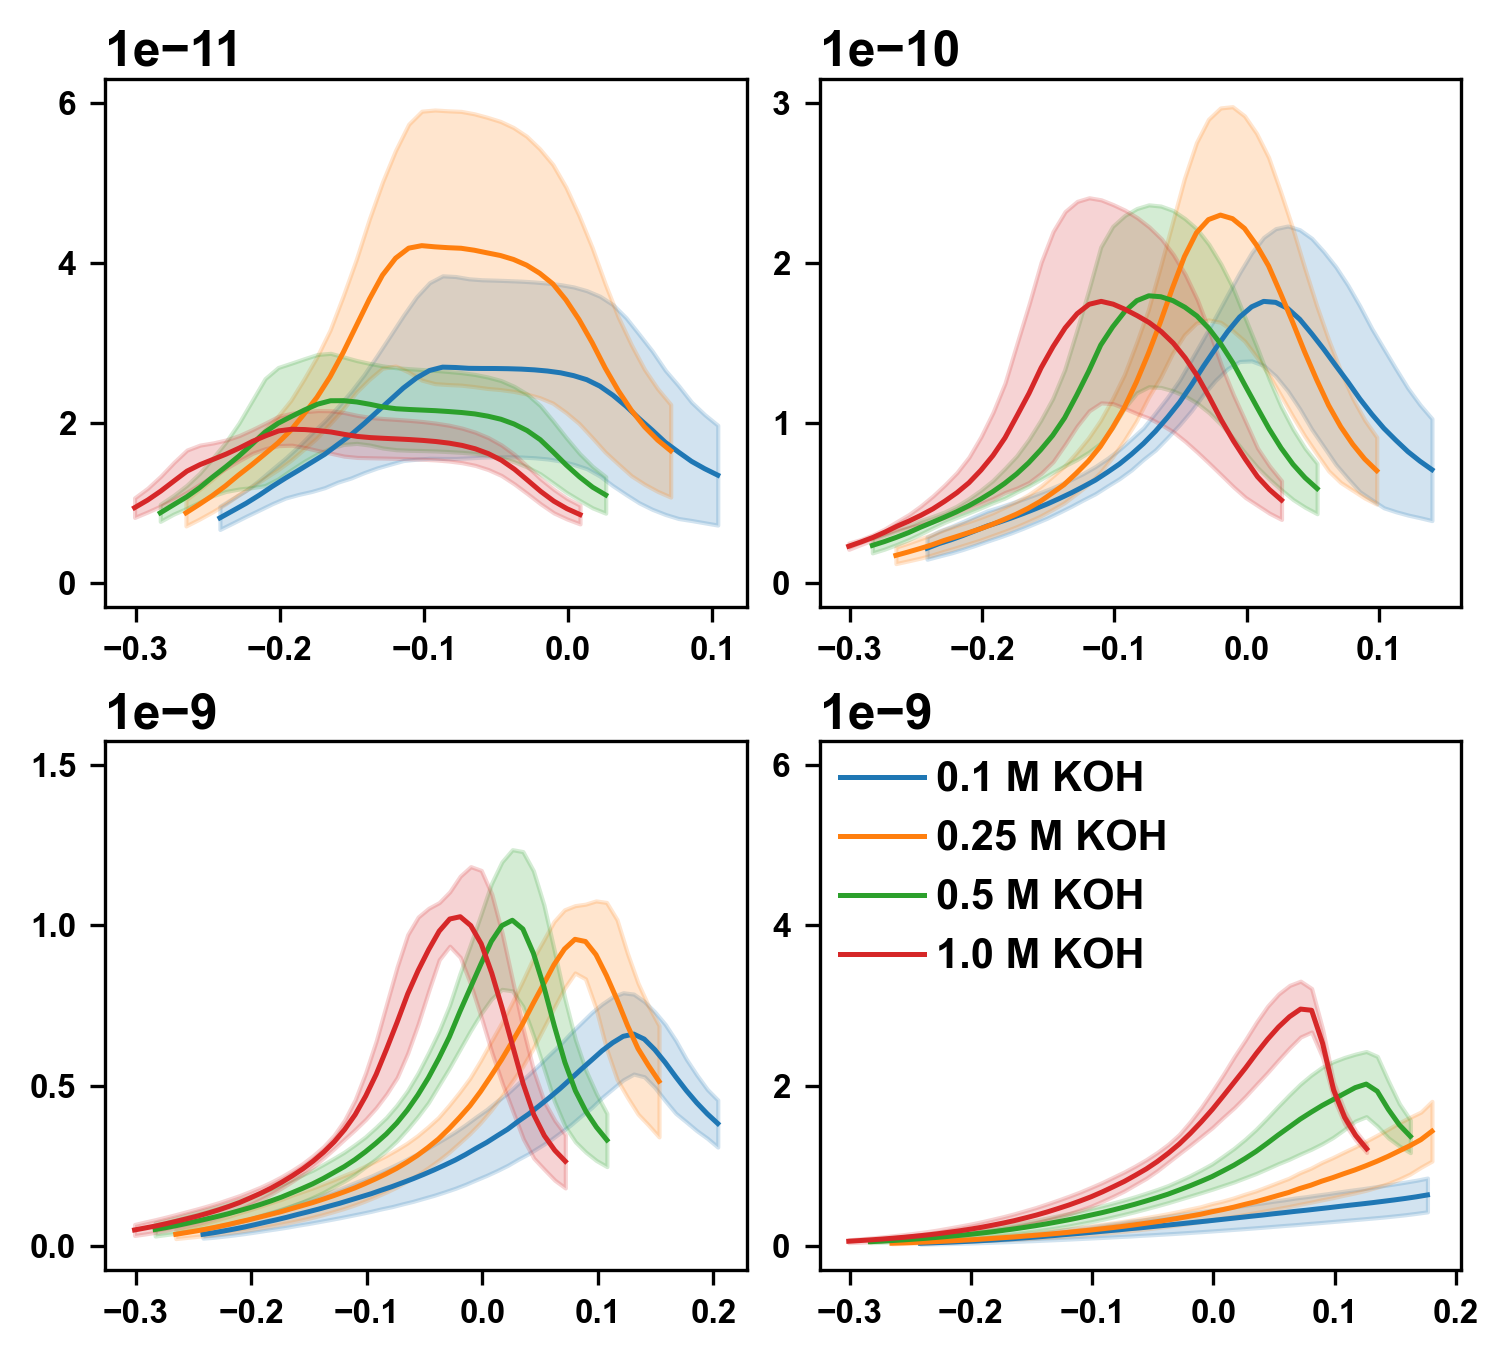

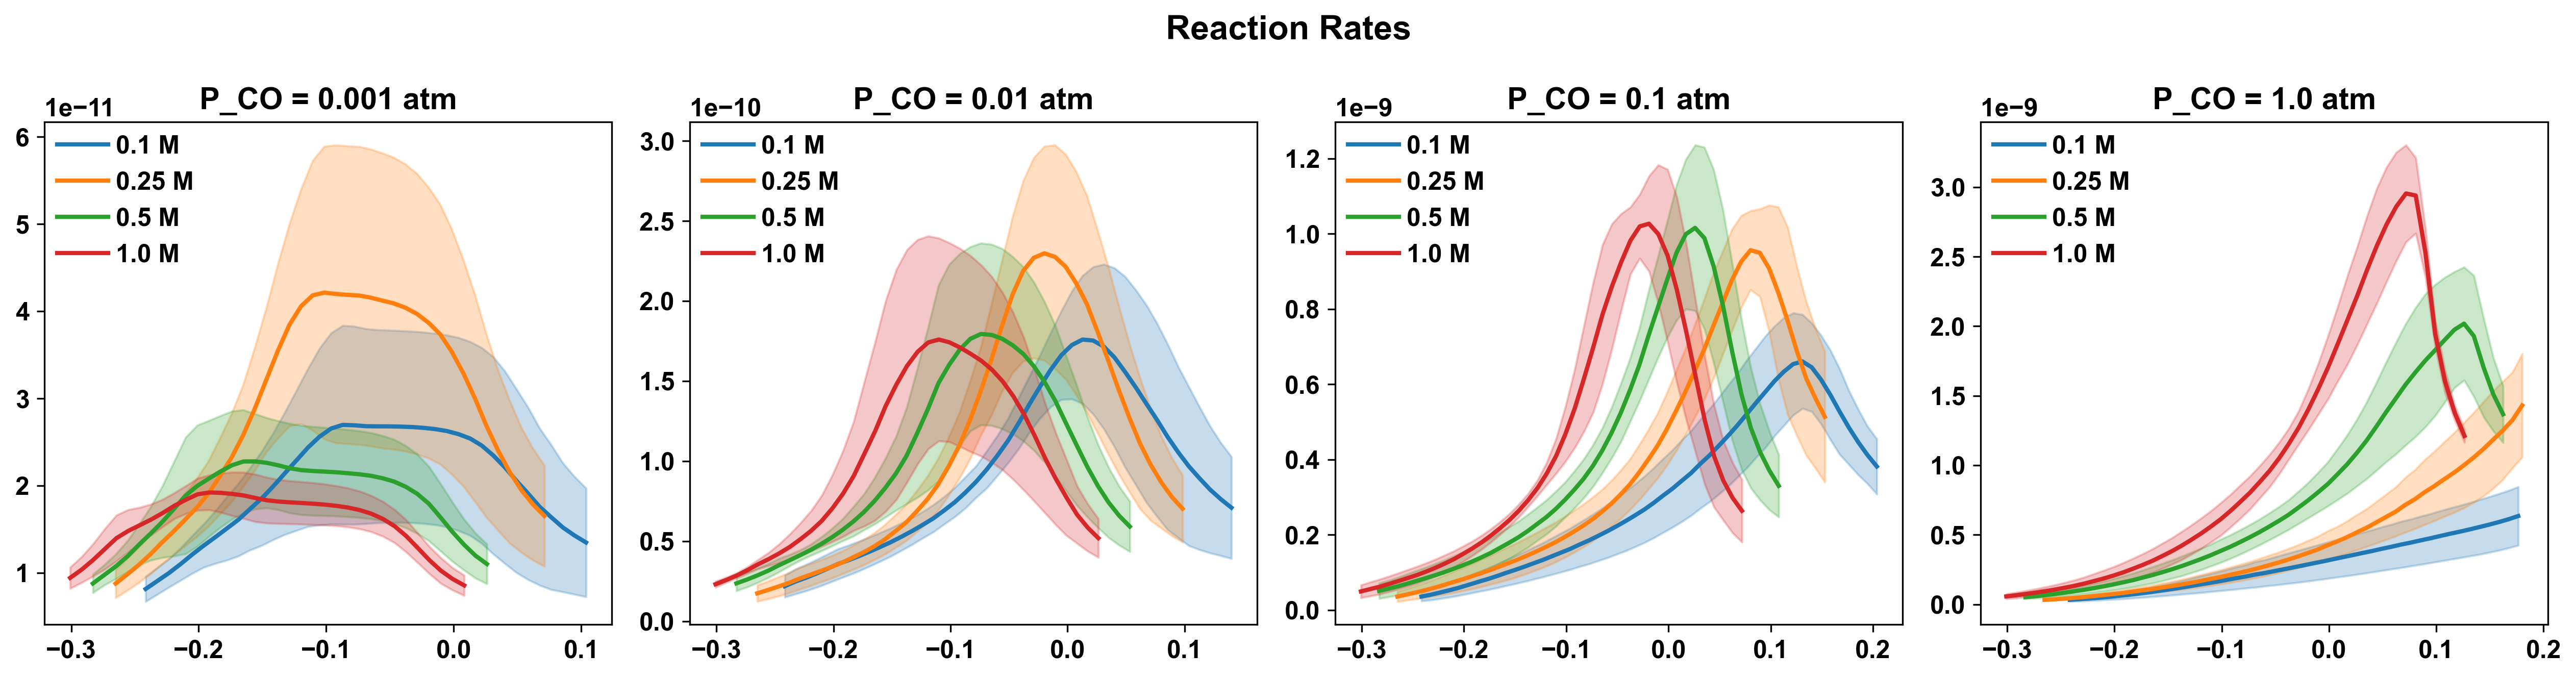

In [5]:

fig = plt.figure(figsize=(5.0, 4.5), dpi=300)
for i, C_KOH in enumerate(C_KOH_list):
    ax = plt.subplot(2, 2, i + 1)
    max_y = 0
    for P_CO in P_CO_list:
        E = experiments_mean[(C_KOH, P_CO)]['E']
        j = experiments_mean[(C_KOH, P_CO)]['rate']
        j_SD = experiments_mean[(C_KOH, P_CO)]['rate_SD']
        line = ax.plot(E, j, label=f'{P_CO} atm CO', linewidth=1.2)
        ax.fill_between(E, j - j_SD, j + j_SD, color=line[0].get_color(), alpha=0.2)
        max_y = max(max_y, np.max(j + j_SD))    
    mag = 10 ** np.floor(np.log10(max_y / 3))
    norm_step = (max_y / 3) / mag
    nice_step = 1 if norm_step <= 1 else 2 if norm_step <= 2 else 2.5 if norm_step <= 2.5 else 5 if norm_step <= 5 else 10
    step = nice_step * mag
    max_tick = 3 * step
    margin = 0.05 * max_tick
    ax.set_yticks([0, step, 2 * step, max_tick])
    ax.set_ylim(-margin, max_tick + margin)
    ax.tick_params(axis='both', labelsize=8)
    if i == 0: ax.legend(fontsize=10, frameon=False, loc='upper left')
plt.tight_layout(pad=0.5)
plt.show()


fig = plt.figure(figsize=(17, 4.5))
fig.suptitle('Reaction Rates', fontsize=16, fontweight='bold')
for i, C_KOH in enumerate(C_KOH_list):
    ax = plt.subplot(1, 4, i + 1)
    plt.title(f'C_KOH = {C_KOH} M')
    for P_CO in P_CO_list:
        E = experiments_mean[(C_KOH, P_CO)]['E']
        j = experiments_mean[(C_KOH, P_CO)]['rate']
        j_SD = experiments_mean[(C_KOH, P_CO)]['rate_SD']
        line = ax.plot(E, j, label=f'{P_CO} atm', linewidth=2)
        ax.fill_between(E, j - j_SD, j + j_SD, color=line[0].get_color(), alpha=0.25)
    plt.legend()
plt.tight_layout()


fig = plt.figure(figsize=(5.0, 4.5), dpi=300)
for i, P_CO in enumerate(P_CO_list):
    ax = plt.subplot(2, 2, i + 1)
    max_y = 0
    for C_KOH in C_KOH_list:
        condition = (C_KOH, P_CO)
        E = experiments_mean[condition]['E']
        j = experiments_mean[condition]['rate']
        j_SD = experiments_mean[condition]['rate_SD'] 
        line = ax.plot(E, j, label=f'{C_KOH} M KOH', linewidth=1.2)
        ax.fill_between(E, j - j_SD, j + j_SD, color=line[0].get_color(), alpha=0.2)
        max_y = max(max_y, np.max(j + j_SD))    
    mag = 10 ** np.floor(np.log10(max_y / 3))
    norm_step = (max_y / 3) / mag
    nice_step = 1 if norm_step <= 1 else 2 if norm_step <= 2 else 2.5 if norm_step <= 2.5 else 5 if norm_step <= 5 else 10
    step = nice_step * mag
    max_tick = 3 * step
    margin = 0.05 * max_tick
    ax.set_yticks([0, step, 2 * step, max_tick])
    ax.set_ylim(-margin, max_tick + margin)
    ax.tick_params(axis='both', labelsize=8)
    if i == 3: ax.legend(fontsize=10, frameon=False, loc='upper left')
plt.tight_layout(pad=0.5)
plt.show()


fig = plt.figure(figsize=(17, 4.5))
fig.suptitle('Reaction Rates', fontsize=16, fontweight='bold')
for i, P_CO in enumerate(P_CO_list):
    ax = plt.subplot(1, 4, i + 1) 
    plt.title(f'P_CO = {P_CO} atm')
    for C_KOH in C_KOH_list:
        condition = (C_KOH, P_CO)
        E = experiments_mean[condition]['E']
        j = experiments_mean[condition]['rate']
        j_SD = experiments_mean[condition]['rate_SD'] 
        line = ax.plot(E, j, label=f'{C_KOH} M', linewidth=2)
        ax.fill_between(E, j - j_SD, j + j_SD, color=line[0].get_color(), alpha=0.25)
    plt.legend()
plt.tight_layout()

In [6]:
# Load Todd's alpha data + classification

alpha_todd_raw = pd.read_excel('Summary_Pt_replicates.xlsx', sheet_name='TC')
alpha_todd = {}
for i, (C_KOH, P_CO) in enumerate(conditions):
    col_idx = i * 3
    subset = alpha_todd_raw.iloc[3:, col_idx : col_idx+3].copy()
    subset.columns = ['E', 'alpha', 'alpha_SD'] # in RHE
    subset = subset.dropna()
    alpha_todd[(C_KOH, P_CO)] = subset
    
    E_ref = 0 - 0.0592*(14 + np.log10(C_KOH))
    alpha_todd[(C_KOH, P_CO)]['E'] = alpha_todd[(C_KOH, P_CO)]['E'] + E_ref

In [7]:
# Calculate alpha from current data

for condition_trial in conditions_trials:
    E = experiments_interp[condition_trial]['E']
    lnj = experiments_interp[condition_trial]['log_rate']

    alpha = (R*T/F)*np.gradient(lnj, E)    
    experiments_interp[condition_trial]['alpha'] = alpha

for condition in conditions:
    C_KOH, P_CO = condition
    alpha_trials = []
    for trial in trials:
        condition_trial = (C_KOH, P_CO, trial)
        alpha_trials.append(experiments_interp[condition_trial]['alpha'])
    alpha_array = np.array(alpha_trials)
    experiments_mean[condition]['alpha'] = np.mean(alpha_array, axis=0)
    experiments_mean[condition]['alpha_SD'] = np.std(alpha_array, axis=0, ddof=1)

# Transfer Coefficients

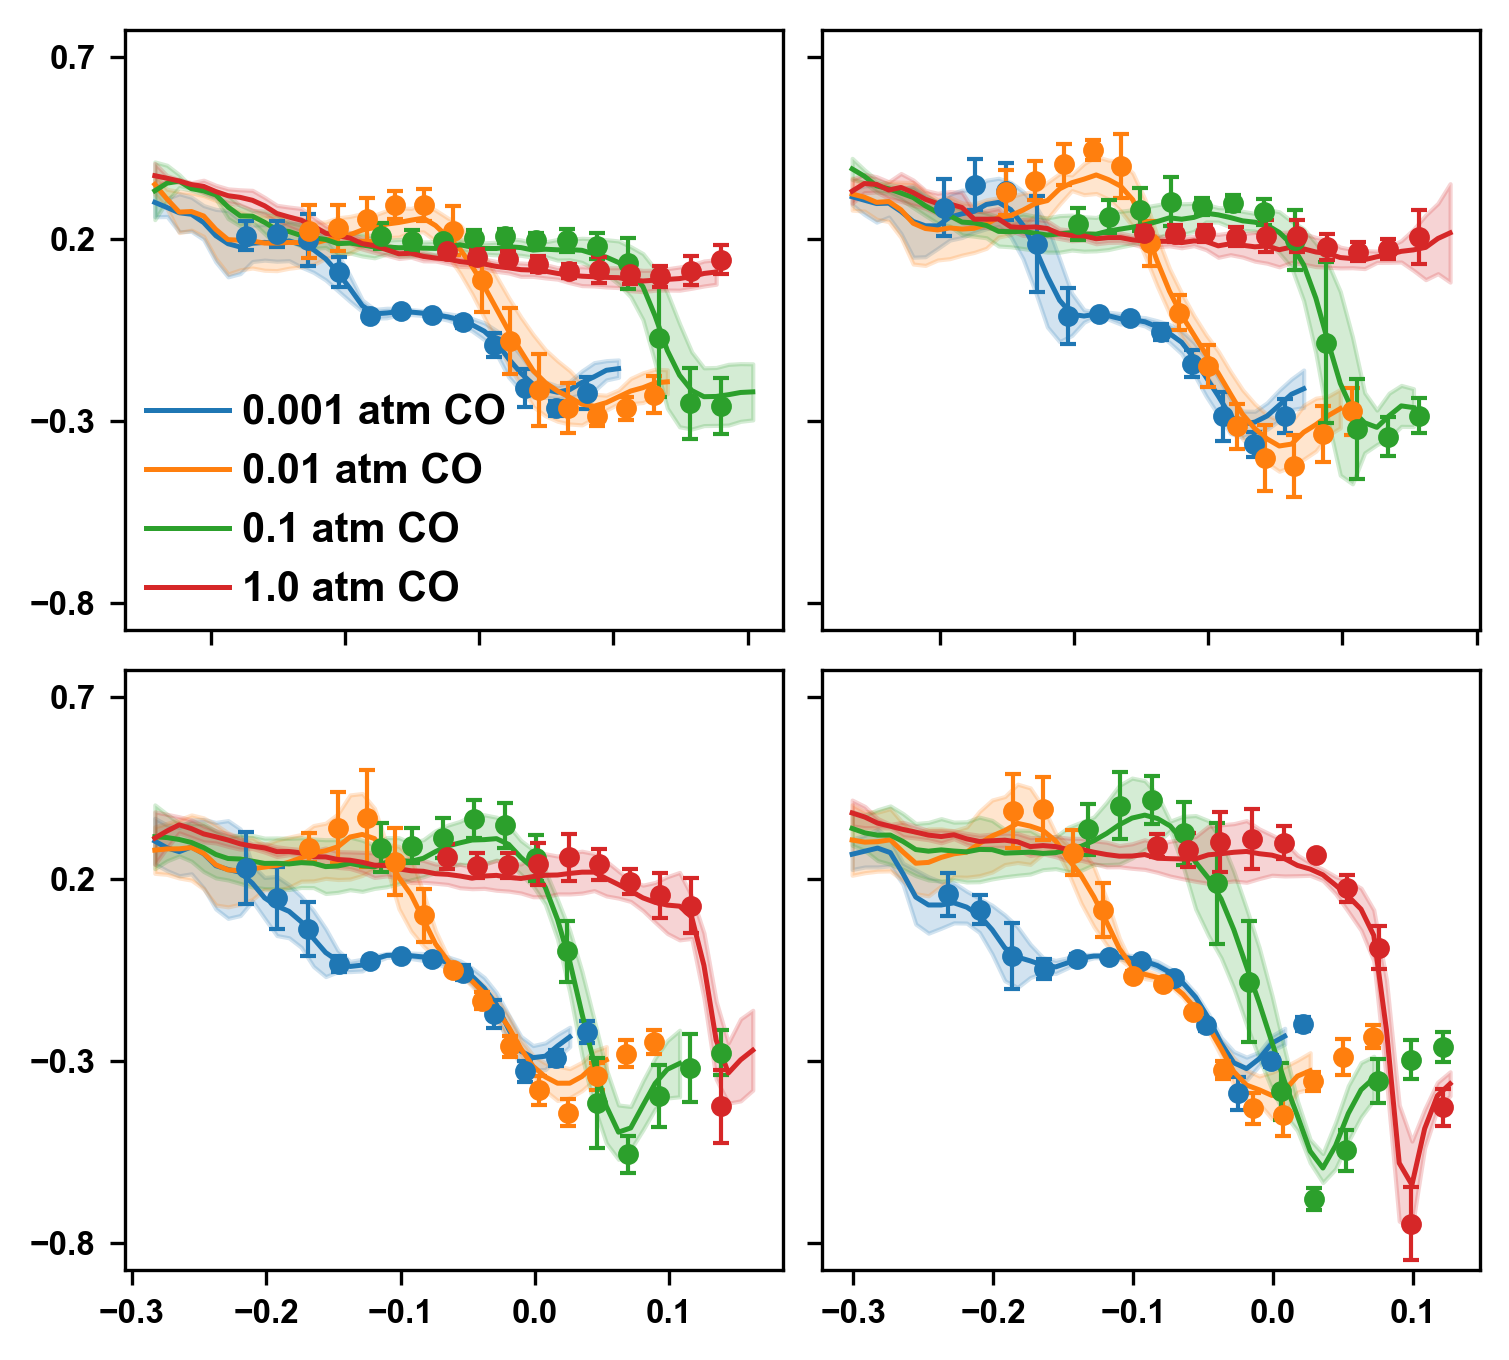

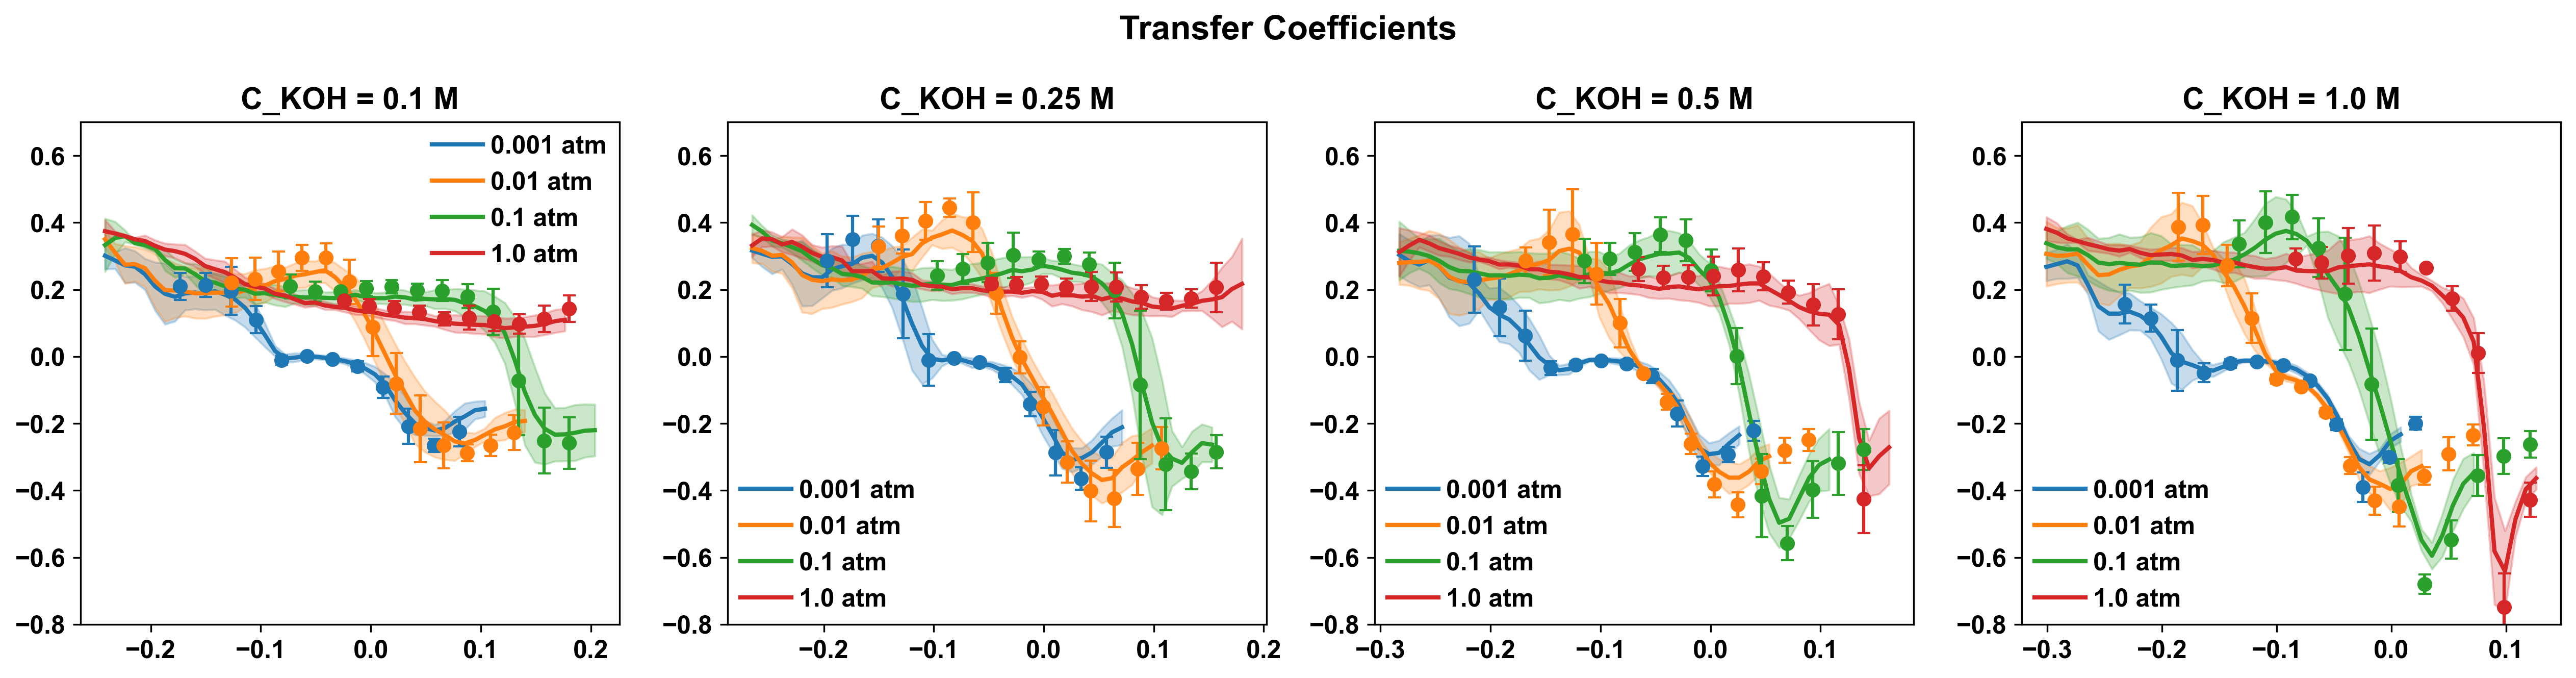

In [8]:
# Plotting alphas 

fig = plt.figure(figsize=(5.0, 4.5), dpi=300)
for i, C_KOH in enumerate(C_KOH_list):
    ax = plt.subplot(2, 2, i + 1) 
    for P_CO in P_CO_list:
        condition = (C_KOH, P_CO)
        E = experiments_mean[condition]['E']
        alpha = experiments_mean[condition]['alpha']
        alpha_SD = experiments_mean[condition]['alpha_SD']
        line = ax.plot(E, alpha, label=f'{P_CO} atm CO', linewidth=1.2)
        ax.fill_between(E, alpha - alpha_SD, alpha + alpha_SD, color=line[0].get_color(), alpha=0.2)
        
        E_todd = alpha_todd[condition]['E']
        alpha_todd_val = alpha_todd[condition]['alpha']
        alpha_todd_SD = alpha_todd[condition]['alpha_SD']
        ax.errorbar(E_todd, alpha_todd_val, yerr=alpha_todd_SD, fmt='o', markersize=4, color=line[0].get_color(), capsize=2, elinewidth=1.0)
        
    span = 0.7 - (-0.8)
    margin = 0.05 * span
    
    ax.set_yticks([-0.8, -0.3, 0.2, 0.7])
    ax.set_ylim(-0.8 - margin, 0.7 + margin)
    ax.tick_params(axis='both', labelsize=8)
    
    if i < 2: ax.tick_params(labelbottom=False)
    if i % 2 != 0: ax.tick_params(labelleft=False)
    
    if i == 0: ax.legend(fontsize=10, frameon=False, loc='lower left')

plt.tight_layout(pad=0.5)
plt.show()


fig = plt.figure(figsize=(17, 4.5))
fig.suptitle('Transfer Coefficients', fontsize=16, fontweight='bold')
for i, C_KOH in enumerate(C_KOH_list):
    ax = plt.subplot(1, 4, i + 1) 
    plt.title(f'C_KOH = {C_KOH} M') 
    for P_CO in P_CO_list:
        condition = (C_KOH, P_CO)
        E = experiments_mean[condition]['E']
        alpha = experiments_mean[condition]['alpha']
        alpha_SD = experiments_mean[condition]['alpha_SD']
        line = ax.plot(E, alpha, label=f'{P_CO} atm', linewidth=2)
        ax.fill_between(E, alpha - alpha_SD, alpha + alpha_SD, color=line[0].get_color(), alpha=0.25)
        
        E_todd = alpha_todd[condition]['E']
        alpha_todd_val = alpha_todd[condition]['alpha']
        alpha_todd_SD = alpha_todd[condition]['alpha_SD']
        ax.errorbar(E_todd, alpha_todd_val, yerr=alpha_todd_SD, fmt='o', markersize=6, color=line[0].get_color(), capsize=3, elinewidth=1.5)
        
    ax.set_ylim(-0.8, 0.7)
    ax.legend()
plt.tight_layout()

In [9]:
import pickle

with open('Pt100_KOH_replicates.pkl', 'wb') as f:
    pickle.dump(experiments_mean, f)

In [10]:
# Load Todd's delta_OH data + classification

delta_OH_todd_raw = pd.read_excel('Summary_Pt_replicates.xlsx', sheet_name='OH- Order')
delta_OH_todd = {}
for i, P_CO in enumerate(P_CO_list):
    col_idx = i * 3
    subset = delta_OH_todd_raw.iloc[3:, col_idx : col_idx+3].copy()
    subset.columns = ['E', 'delta_OH', 'delta_OH_SD'] # in SHE
    subset = subset.dropna()
    delta_OH_todd[(P_CO)] = subset

In [11]:
# Calculate delta_OH from current data

for P_CO in P_CO_list:
    for trial in trials:
        j_interp_matrix = []
        for C_KOH in C_KOH_list:
            j_interp_matrix.append(experiments_interp[(C_KOH, P_CO, trial)]['j'])
        delta_OH = np.polyfit(np.log(C_KOH_list).transpose(), np.log(j_interp_matrix), deg=1)[0]
        for C_KOH in C_KOH_list: experiments_interp[(C_KOH, P_CO, trial)]['delta_OH'] = delta_OH    

for condition in conditions: 
    C_KOH, P_CO = condition
    delta_OH_trials = [experiments_interp[(C_KOH, P_CO, trial)]['delta_OH'] for trial in trials]
    delta_OH_array = np.array(delta_OH_trials)
    experiments_mean[condition]['delta_OH'] = np.mean(delta_OH_array, axis=0)
    experiments_mean[condition]['delta_OH_SD'] = np.std(delta_OH_array, axis=0, ddof=1)

KeyError: 'j'

# OH Reaction Order

In [ ]:
# Plotting delta_OH

'''
fig = plt.figure(figsize=(2.75, 2.4), dpi=300)
ax = plt.subplot(1, 1, 1)
for P_CO in P_CO_list:
    delta_OH = experiments_mean[(C_KOH_list[1], P_CO)]['delta_OH'] 
    delta_OH_SD = experiments_mean[(C_KOH_list[1], P_CO)]['delta_OH_SD'] 
    E_SHE = experiments_mean[(C_KOH_list[1], P_CO)]['E'] 
    line = ax.plot(E_SHE, delta_OH, label=f'{P_CO} atm CO', linewidth=1.2) 
    ax.fill_between(E_SHE, delta_OH - delta_OH_SD, delta_OH + delta_OH_SD, color=line[0].get_color(), alpha=0.2)
    E_todd = delta_OH_todd[(P_CO)]['E']
    delta_OH_todd_val = delta_OH_todd[(P_CO)]['delta_OH']
    delta_OH_todd_SD = delta_OH_todd[(P_CO)]['delta_OH_SD']
    ax.errorbar(E_todd, delta_OH_todd_val, yerr=delta_OH_todd_SD, fmt='o', markersize=4, color=line[0].get_color(), capsize=2, elinewidth=1.0)
span = 1.5 - (-1.0)
margin = 0.05 * span
ax.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0, 1.5])
ax.set_ylim(-1.0 - margin, 1.5 + margin)
ax.tick_params(axis='both', labelsize=8)
ax.legend(fontsize=8, frameon=False, loc='upper left', ncols=2)
plt.tight_layout(pad=0.5)
plt.show()
'''

fig = plt.figure(figsize=(4.5, 4), dpi=100)
plt.title('OH Reaction Order', fontsize=16, fontweight='bold')
for i, P_CO in enumerate(P_CO_list):
    delta_OH = experiments_mean[(C_KOH_list[1], P_CO)]['delta_OH'] # Arbitrary C_KOH
    delta_OH_SD = experiments_mean[(C_KOH_list[1], P_CO)]['delta_OH_SD'] # Arbitrary C_KOH
    E_SHE = experiments_mean[(C_KOH_list[1], P_CO)]['E'] # Arbitrary C_KOH
    line, = plt.plot(E_SHE, delta_OH, label=f'{P_CO} atm', alpha=0.5) 
    plt.fill_between(E_SHE, delta_OH - delta_OH_SD, delta_OH + delta_OH_SD, color=line.get_color(), alpha=0.25)
    E_todd = delta_OH_todd[(P_CO)]['E']
    delta_OH_todd_val = delta_OH_todd[(P_CO)]['delta_OH']
    delta_OH_todd_SD = delta_OH_todd[(P_CO)]['delta_OH_SD']
    plt.errorbar(E_todd, delta_OH_todd_val, yerr=delta_OH_todd[(P_CO)]['delta_OH_SD'], fmt='o', markersize=8, color=line.get_color())
plt.legend(ncols=2)
plt.ylim(-1, 1.5)
plt.tight_layout()

In [ ]:
# Load Todd's delta_CO data + classification

delta_CO_todd_raw = pd.read_excel('Summary_Pt_replicates.xlsx', sheet_name='CO order')
delta_CO_todd = {}
conditions_delta_CO = list(itertools.product(C_KOH_list, P_CO_list[0:-1]))
for i, (C_KOH, P_CO) in enumerate(conditions_delta_CO):
    col_idx = i * 3
    subset = delta_CO_todd_raw.iloc[3:, col_idx : col_idx+3].copy()
    subset.columns = ['E', 'delta_CO', 'delta_CO_SD'] # in RHE
    subset = subset.dropna()
    delta_CO_todd[(C_KOH, P_CO)] = subset

    E_ref = 0 - 0.0592*(14 + np.log10(C_KOH))
    delta_CO_todd[(C_KOH, P_CO)]['E'] = delta_CO_todd[(C_KOH, P_CO)]['E'] + E_ref

In [ ]:
# Calculate delta_CO from current data

for (C_KOH, P_CO) in conditions_delta_CO:
    idx = int(np.where(P_CO_list == P_CO)[0][0])
    for trial in trials: 
        E = experiments_interp[(C_KOH, P_CO, trial)]['E']
        j_1 = experiments_interp[(C_KOH, P_CO, trial)]['j']
        j_2 = experiments_interp[(C_KOH, P_CO_list[idx + 1], trial)]['j']
        delta_CO = (np.log(j_2) - np.log(j_1)) / (np.log(P_CO_list[idx + 1]) - np.log(P_CO))
        experiments_interp[(C_KOH, P_CO, trial)]['delta_CO'] = delta_CO

for condition in conditions_delta_CO:
    C_KOH, P_CO = condition
    delta_CO_trials = [experiments_interp[(C_KOH, P_CO, trial)]['delta_CO'] for trial in trials]
    delta_CO_array = np.array(delta_CO_trials)
    experiments_mean[condition]['delta_CO'] = np.mean(delta_CO_array, axis=0)
    experiments_mean[condition]['delta_CO_SD'] = np.std(delta_CO_array, axis=0, ddof=1)

# CO Reaction Order

In [ ]:
# Plotting delta_CO

'''
fig = plt.figure(figsize=(5.0, 4.5), dpi=300)
for i, target_KOH in enumerate(C_KOH_list):
    ax = plt.subplot(2, 2, i + 1)
    for (C_KOH, P_CO) in conditions_delta_CO:
        if C_KOH == target_KOH:
            E = experiments_mean[(C_KOH, P_CO)]['E']
            delta_CO = experiments_mean[(C_KOH, P_CO)]['delta_CO']
            delta_CO_SD = experiments_mean[(C_KOH, P_CO)]['delta_CO_SD']
            # Find the next P_CO for the label
            idx = int(np.where(P_CO_list == P_CO)[0][0])
            P_CO_2 = P_CO_list[idx + 1]
            line = ax.plot(E, delta_CO, label=f'{P_CO} - {P_CO_2} atm', linewidth=1.2)
            ax.fill_between(E, delta_CO - delta_CO_SD, delta_CO + delta_CO_SD, color=line[0].get_color(), alpha=0.2)
            E_todd = delta_CO_todd[(C_KOH, P_CO)]['E']
            delta_CO_todd_val = delta_CO_todd[(C_KOH, P_CO)]['delta_CO']
            delta_CO_todd_SD = delta_CO_todd[(C_KOH, P_CO)]['delta_CO_SD']
            ax.errorbar(E_todd, delta_CO_todd_val, yerr=delta_CO_todd_SD, fmt='o', markersize=4, color=line[0].get_color(), capsize=2, elinewidth=1.0)
    # 5% floating margin
    span = 1.5 - (-0.5)
    margin = 0.05 * span
    ax.set_yticks([-0.5, 0.0, 0.5, 1.0, 1.5])
    ax.set_ylim(-0.5 - margin, 1.5 + margin)
    ax.tick_params(axis='both', labelsize=8)
    # Share axes visually by hiding inner tick labels
    if i < 2: ax.tick_params(labelbottom=False)
    if i % 2 != 0: ax.tick_params(labelleft=False)
    # Legend only in the first plot
    if i == 0:
        ax.legend(fontsize=10, frameon=False, loc='upper left')
plt.tight_layout(pad=0.5)
plt.show()
'''

fig = plt.figure(figsize=(17, 4.5))
fig.suptitle('CO Reaction Order', fontsize=16, fontweight='bold')
for i, target_KOH in enumerate(C_KOH_list):
    plt.subplot(1, 4, i + 1) 
    plt.title(f'C_KOH = {target_KOH} M')
    for (C_KOH, P_CO) in conditions_delta_CO:
        if C_KOH == target_KOH:
            E = experiments_mean[(C_KOH, P_CO)]['E']
            delta_CO = experiments_mean[(C_KOH, P_CO)]['delta_CO']
            delta_CO_SD = experiments_mean[(C_KOH, P_CO)]['delta_CO_SD']
            idx = int(np.where(P_CO_list == P_CO)[0][0])
            P_CO_2 = P_CO_list[idx + 1]
            line, = plt.plot(E, delta_CO, label=f'{P_CO} - {P_CO_2} atm', alpha=0.5)
            plt.fill_between(E, delta_CO - delta_CO_SD, delta_CO + delta_CO_SD, color=line.get_color(), alpha=0.25)
            
            E_todd = delta_CO_todd[(C_KOH, P_CO)]['E']
            delta_CO_todd_val = delta_CO_todd[(C_KOH, P_CO)]['delta_CO']
            delta_CO_todd_SD = delta_CO_todd[(C_KOH, P_CO)]['delta_CO_SD']
            plt.errorbar(E_todd, delta_CO_todd_val, yerr=delta_CO_todd_SD, fmt='o', markersize=8, color=line.get_color(), capsize=3)

    plt.legend()
    plt.ylim(-0.5, 1.5)
plt.tight_layout()

In [ ]:
import pickle

with open('Pt100_KOH_replicates.pkl', 'wb') as f:
    pickle.dump(experiments_mean, f)